In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

In [3]:
file = np.genfromtxt('/Users/eleonora/Desktop/mistral/LUT/TY_data.dat', comments='#')
genn = pd.DataFrame(file, columns=['EL', 'TZ', 'TY', 'err_TY', 'D_el', 'D_az', 's/d'])
#Elevation
#TZ
#best TY
#errore
#DEl armin (alla pos di best focus)
#DAz arcsec
#salita/discesa                                                                                        

'''
mpl.rcParams['lines.markersize'] = 5
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111)
ax.scatter(dati_lut['EL'], dati_lut['TY'], label='data')
ax.errorbar(dati_lut['EL'], dati_lut['TY'], dati_lut['err_TY'])
ax.scatter(dati_lut['EL'], p(dati_lut['EL']), label='fit')
ax.set_xlabel('EL [deg]')
ax.set_ylabel('TY [mm]')
#for i, label in enumerate(dict['TZ']):
#    ax.annotate('TZ'+str(label), (dict['EL'][i], dict['TY_choosen'][i]),  xytext=(5, -5), #, xytext=(20, -20),
#        textcoords='offset points')#, arrowprops=dict(arrowstyle='->'))
plt.legend()
plt.show()
'''

table_csv = '/Users/eleonora/Desktop/SRT-marzo/MATRICI/Tabella_MATRICI.csv'
tab = pd.read_csv(table_csv)

feb = tab[tab['Data']=='febbraio']

mar = tab[tab['Data']!='febbraio'][0:29]

mar


,Data,SORGENTE,AZ,range EL,EL,TZ,err_TZ,TY,err_TY,TZ lin mapping,TY lin mapping
9,20250330-212707,marte,NaN,NaN,47.0,1.0,1.0,-4.0,1.0,1.0,-3.7
10,20250330-214931,marte,NaN,NaN,42.0,1.0,1.0,-1.0,1.0,0.5,-1.0
11,20250330-221030,marte,NaN,NaN,38.0,0.0,1.0,-4.0,1.0,0.0,-3.0
12,20250330-223130,marte,NaN,NaN,34.0,2.0,1.0,-3.0,1.0,2.0,-3.0
13,20250330-225850,3C273,132,NaN,52.0,0.0,1.0,-1.0,1.0,0.5,-1.0
14,20250330-234312,3C345,70,NaN,48.0,1.0,1.0,-2.0,1.0,1.0,-1.5
15,20250331-171034,marte,131,NaN,68.0,-1.0,1.0,-4.0,1.0,-1.0,-3.0
16,20250331-223726,3C273,168,NaN,51.0,0.0,1.0,-3.0,1.0,-0.5,-2.5
17,20250331-232207,3C345,69,NaN,45.0,0.0,1.0,-4.0,1.0,-0.5,-3.5
18,20250401-144639,marte,92,NaN,42.0,1.0,1.0,-2.0,1.0,1.0,-2.0


In [4]:
def add_checkpoints_old(tab):
    el = [0, 15]
    el+= [tab['EL'].values]
    el += [90]
    el = np.hstack(el)

    TY = [-120, -90]
    TY += [tab['TY'].values]
    TY += [25]
    TY = np.hstack(TY)

    err = [1, 1]
    err += [tab['err_TY'].values]
    err += [1]
    err = np.hstack(err)
    return el, TY, err

def add_checkpoints(tabel, tabty, taberr):
    el = [0, 15]
    el+= [tabel]
    el += [90]
    el = np.hstack(el)

    TY = [0, 0]
    TY += [tabty]
    TY += [0]
    TY = np.hstack(TY)

    err = [1, 1]
    err += [taberr]
    err += [1]
    err = np.hstack(err)
    return el, TY, err

            6             5             4            3           2
-7.588e-09 x + 1.931e-06 x - 0.0001673 x + 0.005211 x - 0.03519 x + 1.843 x - 90.45


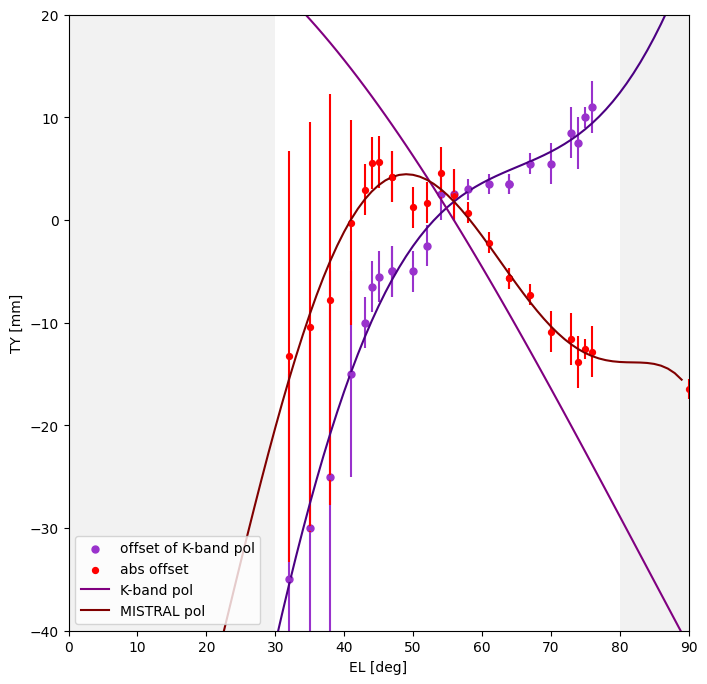

pol mistral feb
           6             5             4            3         2
7.938e-10 x - 3.795e-07 x + 7.329e-05 x - 0.006407 x + 0.217 x - 0.0307 x - 90.45
pol mistral mar
            6             5           4           3          2
-5.922e-09 x + 1.566e-06 x - 0.00014 x + 0.00447 x - 0.0331 x + 1.898 x - 90.44


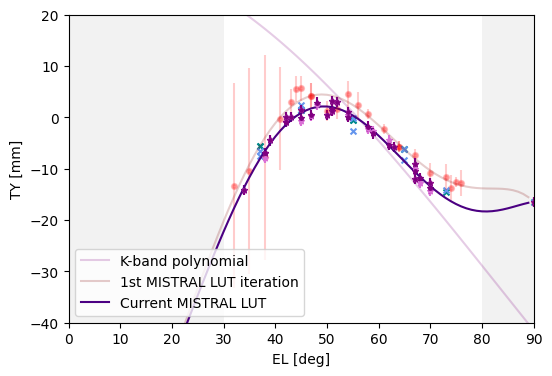

In [10]:
range_el = range(0,90,1)
coeff_K=np.array(list(reversed([29.556666666666498,0.263472663139432,-0.018206701940039,0.000072373113855])))
pol_K = np.poly1d(coeff_K)

genn_el, genn_TY, genn_err = add_checkpoints_old(genn)

fit_genn = np.polyfit(genn_el, genn_TY, deg=5)
pol_offset_MISTRAL_genn = np.poly1d(fit_genn)

orig_data_genn = np.array(pol_K(genn_el)) + np.array(genn_TY)
fit_orig_genn = np.polyfit(genn_el, orig_data_genn, deg=6)
pol_orig_MISTRAL_genn = np.poly1d(fit_orig_genn)
print(pol_orig_MISTRAL_genn) 
#questo è il polinomio inserito in discos a febbraio. Gli offset delle prossime matrici (delle sessioni seguenti) si riferiscono a questo polinomio.
mpl.rcParams['lines.markersize'] = 5
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111)
ax.scatter(genn_el, genn_TY, label='offset of K-band pol', c='darkorchid')
ax.errorbar(genn_el, genn_TY, genn_err, c='darkorchid', fmt='.')
ax.scatter(genn_el, orig_data_genn, label='abs offset', c='red', s=18)
ax.errorbar(genn_el, orig_data_genn, genn_err, c='red', fmt='.')
ax.plot(range_el, pol_offset_MISTRAL_genn(range_el), c='indigo')
ax.plot(range_el, pol_K(range_el), label='K-band pol', c='purple')
ax.plot(range_el, pol_orig_MISTRAL_genn(range_el), label='MISTRAL pol', c='maroon')
ymin = -40
ymax = 20
xmin = 0
xmax = 90
ax.axhspan(ymin, ymax, 0 , 30/xmax, facecolor='grey', alpha=0.1)
ax.axhspan(ymin, ymax, 80/xmax , 90/xmax, facecolor='grey', alpha=0.1)
ax.set_xlabel('EL [deg]')
ax.set_ylabel('TY [mm]')
ax.set_ylim(ymin, ymax)
ax.set_xlim(0,90)
#for i, label in enumerate(dict['TZ']):
#    ax.annotate('TZ'+str(label), (dict['EL'][i], dict['TY_choosen'][i]),  xytext=(5, -5), #, xytext=(20, -20),
#        textcoords='offset points')#, arrowprops=dict(arrowstyle='->'))
plt.legend(loc='lower left')
plt.show()

feb_mat_el = feb['EL']
feb_mat_TY = feb['TY']
feb_mat_TY_linmap = feb['TY lin mapping']
feb_mat_err = feb['err_TY']
feb_mat_el, feb_mat_TY, feb_mat_err = add_checkpoints(feb['EL'].values, feb['TY'].values, feb['err_TY'].values)
feb_mat_el, feb_mat_TY_linmap, feb_mat_err = add_checkpoints(feb['EL'].values, feb['TY lin mapping'].values, feb['err_TY'].values)
feb_mat_TY = np.array(pol_orig_MISTRAL_genn(feb_mat_el)) + np.array(feb_mat_TY)
feb_mat_TY_linmap = np.array(pol_orig_MISTRAL_genn(feb_mat_el)) + np.array(feb_mat_TY_linmap)

fit_matrix_feb = np.polyfit(feb_mat_el, np.mean([feb_mat_TY, feb_mat_TY_linmap], axis=0), deg=6)
pol_MISTRAL_matrix_feb = np.poly1d(fit_matrix_feb)
print('pol mistral feb')
print(pol_MISTRAL_matrix_feb)

mar_mat_el = mar['EL']
mar_mat_TY = mar['TY']
mar_mat_TY_linmap = mar['TY lin mapping']
mar_mat_err = mar['err_TY']
mar_mat_el, mar_mat_TY, mar_mat_err = add_checkpoints(mar['EL'].values, mar['TY'].values, mar['err_TY'].values)
mar_mat_el, mar_mat_TY_linmap, mar_mat_err = add_checkpoints(mar['EL'].values, mar['TY lin mapping'].values, mar['err_TY'].values)
mar_mat_TY = np.array(pol_orig_MISTRAL_genn(mar_mat_el)) + np.array(mar_mat_TY)
mar_mat_TY_linmap = np.array(pol_orig_MISTRAL_genn(mar_mat_el)) + np.array(mar_mat_TY_linmap)

fit_matrix_mar = np.polyfit(mar_mat_el, np.mean([mar_mat_TY, mar_mat_TY_linmap], axis=0), deg=6)
pol_MISTRAL_matrix_mar = np.poly1d(fit_matrix_mar)
print('pol mistral mar')
print(pol_MISTRAL_matrix_mar)

mpl.rcParams['lines.markersize'] = 5
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111)
ax.plot(range_el, pol_K(range_el), label='K-band polynomial', c='purple', alpha=0.2)
ax.scatter(genn_el, orig_data_genn, c='red', alpha=0.2, s=18)
ax.errorbar(genn_el, orig_data_genn, genn_err, c='red', fmt='.', alpha=0.2)
ax.plot(range_el, pol_orig_MISTRAL_genn(range_el), label='1st MISTRAL LUT iteration', c='maroon', alpha=0.2) #label='Jan MISTRAL polynomial'
ax.scatter(feb_mat_el, feb_mat_TY, color='darkcyan', s=18, marker='x')
ax.scatter(feb_mat_el, feb_mat_TY_linmap, color='cornflowerblue', s=18, marker='x')
#ax.plot(range_el, pol_MISTRAL_matrix_feb(range_el), label='Feb MISTRAL polynomial', c='cadetblue')
ax.scatter(mar_mat_el, mar_mat_TY, color='orchid', s=18, marker='*')
ax.errorbar(mar_mat_el, mar_mat_TY, mar_mat_err, c='orchid', fmt='.')
ax.scatter(mar_mat_el, mar_mat_TY_linmap, color='purple', s=18, marker='*')
ax.errorbar(mar_mat_el, mar_mat_TY_linmap, mar_mat_err, c='purple', fmt='.')
ax.plot(range_el, pol_MISTRAL_matrix_mar(range_el), label='Current MISTRAL LUT', c='indigo')
#ymin = -100
#ymax = 40
#xmin = 0
#xmax = 90
ax.axhspan(ymin, ymax, 0 , 30/xmax, facecolor='grey', alpha=0.1)
ax.axhspan(ymin, ymax, 80/xmax , 90/xmax, facecolor='grey', alpha=0.1)
ax.set_xlabel('EL [deg]')
ax.set_ylabel('TY [mm]')
ax.set_ylim(ymin, ymax)
ax.set_xlim(0,90)
#for i, label in enumerate(dict['TZ']):
#    ax.annotate('TZ'+str(label), (dict['EL'][i], dict['TY_choosen'][i]),  xytext=(5, -5), #, xytext=(20, -20),
#        textcoords='offset points')#, arrowprops=dict(arrowstyle='->'))
plt.legend(loc='lower left')
plt.show()


[52. 48. 68. 51. 45. 42. 38. 42. 45. 50. 54. 58. 62. 67. 67. 43. 51. 39.
 51. 54. 59. 63. 67. 70. 70.]
131.0 68.0 -4.0
79.0 67.0 -4.0
128.0 67.0 -1.0
125.0 67.0 -2.0
142.0 70.0 -4.0
217.0 70.0 -2.5


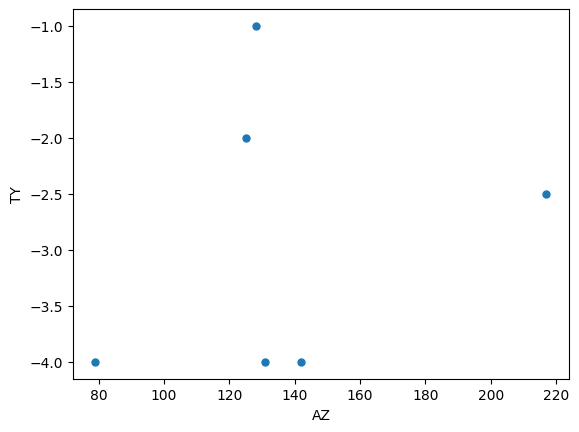

In [46]:
azs = np.array(mar['AZ'][4:], dtype=float)
els = np.array(mar['EL'][4:], dtype=float)
tys = np.array(mar['TY'][4:], dtype=float)
print(els)

el50 = []
az50 = []
ty50 = []#
for i in range(len(els)):
    if els[i]<71 and els[i]>66:
        print(azs[i], els[i], tys[i])
        el50.append(els[i])
        az50.append(azs[i])
        ty50.append(tys[i])

plt.scatter(az50, ty50)
for az, el, ty in zip(azs, els, tys):
    ax.annotate('EL'+str(el), (az, ty),  xytext=(5, -5), textcoords='offset points')#, arrowprops=dict(arrowstyle='->'))
plt.xlabel('AZ')
plt.ylabel('TY')
plt.show()

In [24]:
azs

array(['132', '70', '131', '168', '69', '92', '66', '68', '69', '72',
       '74', '75', '77', '79', '128', '137', '167', '230', '231', '105',
       '110', '120', '125', '142', '217'], dtype=object)

In [6]:
dict = {
    #'EL' : [46, 48, 48, 51, 52, 52, 54, 55, 55, 64, 67, 73, 78],
    #'TZ' : [-7, -7, -7, -7, -7, -7, -8, -7, -7, -7, -6, -7, -7],
    #'bestTY' : [-5, -2.5, -5, -4, 0, -2.5, -5, -2.5, 0, 5, 5, 10, 10],
    'EL' : [46, 48, 51, 52, 54, 64, 67, 73, ], # 78],
    'TZ' : [-7, -7, -7, -7, -8, -7, -6, -7, ], # -7],
    'TY_choosen' : [-5, -5, -4, -2.5, -2.5, 5, 5, 12.5, ], # 10],
    'bestA' : [-6.5, -3.6, -3.6, -3.5, -2.7, 4.2, 2.7, 8, ],
    'bestFWHM' : [-4.5, -3.7, -3.9, -3.8, -4.4, 3.0, 10, 5, ],
    'Dsigma': [-5, -2.5,  -2, -5, -2.5, -2.5, 5, 12.5, ],
    'ell': [-5, -2.5,  -2, -5, -2.5, -2.5, 5, 12.5, ],
    'AZoffset' : [],
    'ELoffset' : [],
}

dict

{'EL': [46, 48, 51, 52, 54, 64, 67, 73],
 'TZ': [-7, -7, -7, -7, -8, -7, -6, -7],
 'TY_choosen': [-5, -5, -4, -2.5, -2.5, 5, 5, 12.5],
 'bestA': [-6.5, -3.6, -3.6, -3.5, -2.7, 4.2, 2.7, 8],
 'bestFWHM': [-4.5, -3.7, -3.9, -3.8, -4.4, 3.0, 10, 5],
 'Dsigma': [-5, -2.5, -2, -5, -2.5, -2.5, 5, 12.5],
 'ell': [-5, -2.5, -2, -5, -2.5, -2.5, 5, 12.5],
 'AZoffset': [],
 'ELoffset': []}

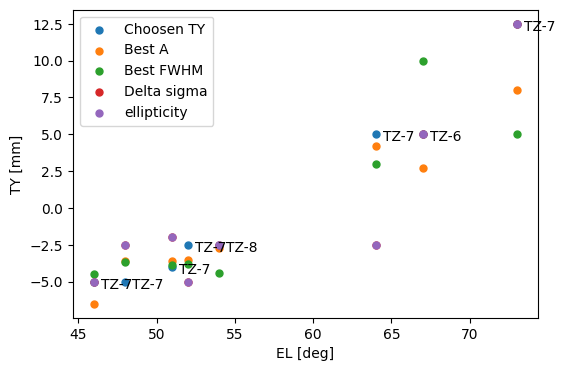

In [7]:
mpl.rcParams['lines.markersize'] = 5
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111)
ax.scatter(dict['EL'], dict['TY_choosen'], label='Choosen TY')
ax.scatter(dict['EL'], dict['bestA'], label='Best A')
ax.scatter(dict['EL'], dict['bestFWHM'], label='Best FWHM')
ax.scatter(dict['EL'], dict['Dsigma'], label='Delta sigma')
ax.scatter(dict['EL'], dict['ell'], label='ellipticity')
ax.set_xlabel('EL [deg]')
ax.set_ylabel('TY [mm]')
for i, label in enumerate(dict['TZ']):
    ax.annotate('TZ'+str(label), (dict['EL'][i], dict['TY_choosen'][i]),  xytext=(5, -5), #, xytext=(20, -20),
        textcoords='offset points')#, arrowprops=dict(arrowstyle='->'))
plt.legend(loc='upper left')
plt.show()

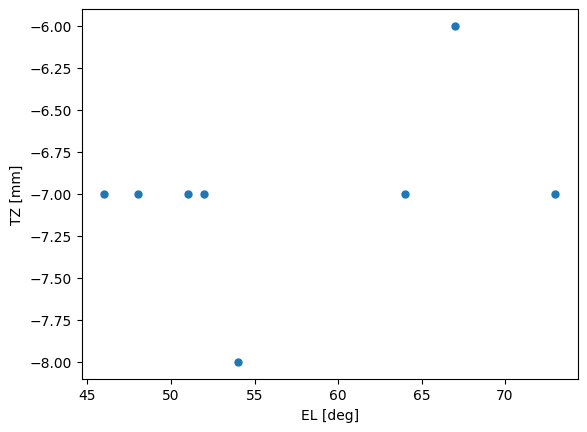

In [8]:
plt.scatter(dict['EL'], dict['TZ'])
plt.xlabel('EL [deg]')
plt.ylabel('TZ [mm]')
plt.show()